In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

# 1. Load Data
df = pd.read_csv(r"C:\Users\Dell\Documents\GitHub\DS111\Data\Gold\Gold_1.csv")

# 2. Tự động nhận diện các cột Numeric quan trọng đang có
potential_cols = ['pv_rank', 'va_rank', 'rl_rank', 'cc_rank', 
                  'Log_Export', 'Tariff_Gap', 'Country_Growth_Percent',
                  'AHS_Duty_Free_Tariff_Lines_Share_Percent']
# Lấy những cột thực sự có trong file
available_cols = [c for c in potential_cols if c in df.columns]

print(f"File loaded. Shape: {df.shape}")
print("Các cột quan trọng được tìm thấy:", available_cols)

File loaded. Shape: (5500, 13)
Các cột quan trọng được tìm thấy: ['pv_rank', 'va_rank', 'Log_Export', 'Tariff_Gap', 'Country_Growth_Percent', 'AHS_Duty_Free_Tariff_Lines_Share_Percent']


# 1. Kiểm tra phân phối và logic dữ liệu

Sai số lớn nhất của Tariff Gap: 31.94

=== Distribution Insights (Skew/Kurt) ===
                                           Skewness  Kurtosis
pv_rank                                   0.245184 -1.101650
va_rank                                   0.230224 -1.158768
Log_Export                               -0.421745  1.775979
Tariff_Gap                                2.173848  9.925611
Country_Growth_Percent                    0.054414  0.502606
AHS_Duty_Free_Tariff_Lines_Share_Percent -0.162993 -0.959903


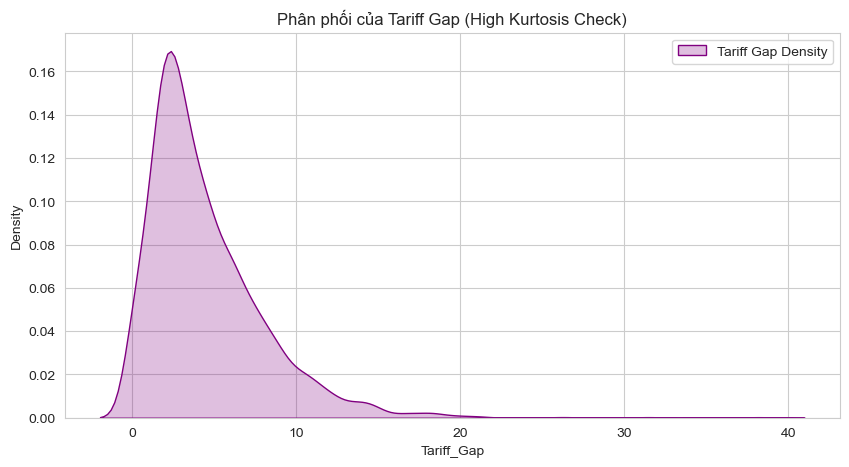

In [2]:
# 1. Logic Check: Tariff Gap
# Kiểm tra xem Gap có đúng bằng MFN - AHS không
if 'MFN_Weighted_Average_Percent' in df.columns and 'AHS_Weighted_Average_Percent' in df.columns:
    df['Calc_Gap'] = df['MFN_Weighted_Average_Percent'] - df['AHS_Weighted_Average_Percent']
    df['Logic_Diff'] = df['Calc_Gap'] - df['Tariff_Gap']
    print("Sai số lớn nhất của Tariff Gap:", df['Logic_Diff'].abs().max())

# 2. Skewness & Kurtosis Analysis
# Insight: Kurtosis cao ở Tariff_Gap cho thấy có những nước "bảo hộ cực đoan" (Outliers)
dist_stats = pd.DataFrame({
    'Skewness': df[available_cols].skew(),
    'Kurtosis': df[available_cols].kurtosis()
})
print("\n=== Distribution Insights (Skew/Kurt) ===\n", dist_stats)

# Visualizing the Fat Tail of Tariff Gap
plt.figure(figsize=(10, 5))
sns.kdeplot(df['Tariff_Gap'], fill=True, color='purple', label='Tariff Gap Density')
plt.title('Phân phối của Tariff Gap (High Kurtosis Check)')
plt.legend()
plt.show()

1.  **Về Logic (Tariff Gap):** Sai số tính toán lên tới `31.94` cho thấy `Tariff_Gap` trong dữ liệu gốc không đơn thuần là hiệu số `MFN - AHS`. Có thể nó được tính dựa trên công thức trọng số phức tạp hơn hoặc dữ liệu có nhiễu. Cần lưu ý điều này khi giải thích các outliers.
2.  **Về Phân phối (Distribution):**
    * **Tariff_Gap:** Có **Kurtosis cực cao (~9.9)** và **Skewness dương (~2.17)**. Điều này xác nhận giả thuyết về "Fat Tails": Đa số quốc gia có chênh lệch thuế thấp, nhưng tồn tại một nhóm nhỏ các nước có mức bảo hộ cực đoan (outliers) làm kéo dài đuôi phân phối.
    * **Governance Ranks (pv_rank/va_rank):** Kurtosis âm (~ -1.1) cho thấy phân phối khá phẳng (uniform), phản ánh đúng tính chất của dữ liệu xếp hạng (rank).

# 2. Case Study

- Chia nhóm nước dựa trên quy mô xuất khẩu (Log_Export) để xem Governance tác động khác nhau thế nào

In [ ]:
# 1. Phân loại Nước Lớn (Big Players) vs Nước Nhỏ (Small Players)
# Dùng Quantile: Top 30% là Lớn, Bottom 30% là Nhỏ
high_threshold = df['Log_Export'].quantile(0.70)
low_threshold = df['Log_Export'].quantile(0.30)

def classify_size(val):
    if val >= high_threshold: return 'Large Country'
    if val <= low_threshold: return 'Small Country'
    return 'Medium'

df['Country_Size'] = df['Log_Export'].apply(classify_size)

# 2. So sánh chỉ số trung bình giữa các nhóm
group_comparison = df.groupby('Country_Size')[['pv_rank', 'Tariff_Gap', 'AHS_Duty_Free_Tariff_Lines_Share_Percent']].mean()
print("\n=== COMPARISON: LARGE vs SMALL ===\n", group_comparison)

# 3. Phân tích Tương quan riêng cho từng nhóm (Core Insight)
# Check xem Governance (pv_rank) có giảm được Gap ở từng nhóm không?
for size in ['Large Country', 'Small Country']:
    subset = df[df['Country_Size'] == size]
    corr = subset['pv_rank'].corr(subset['Tariff_Gap'])
    print(f"Correlation (Governance vs Gap) in {size}: {corr:.4f}")



=== COMPARISON: LARGE vs SMALL ===
                  pv_rank  Tariff_Gap  AHS_Duty_Free_Tariff_Lines_Share_Percent
Country_Size                                                                  
Large Country  46.844276    2.364955                                 46.529588
Medium         41.158390    4.702174                                 59.663574
Small Country  45.705030    6.364933                                 65.091824
Correlation (Governance vs Gap) in Large Country: -0.3888
Correlation (Governance vs Gap) in Small Country: 0.0039


# 4. Visualization cho Case Study

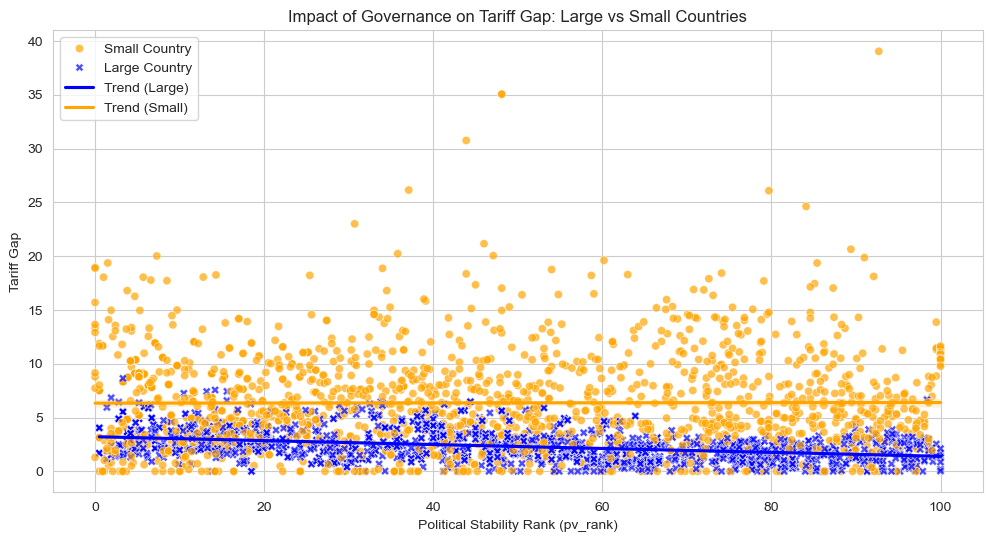

In [4]:
# Lọc chỉ lấy nhóm Large và Small để so sánh rõ hơn
subset_viz = df[df['Country_Size'].isin(['Large Country', 'Small Country'])]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=subset_viz, x='pv_rank', y='Tariff_Gap', 
                hue='Country_Size', style='Country_Size', 
                palette={'Large Country': 'blue', 'Small Country': 'orange'},
                alpha=0.7)

# Thêm đường xu hướng (Trendline) để thấy sự khác biệt về độ dốc
sns.regplot(data=subset_viz[subset_viz['Country_Size']=='Large Country'], 
            x='pv_rank', y='Tariff_Gap', scatter=False, color='blue', label='Trend (Large)')
sns.regplot(data=subset_viz[subset_viz['Country_Size']=='Small Country'], 
            x='pv_rank', y='Tariff_Gap', scatter=False, color='orange', label='Trend (Small)')

plt.title('Impact of Governance on Tariff Gap: Large vs Small Countries')
plt.xlabel('Political Stability Rank (pv_rank)')
plt.ylabel('Tariff Gap')
plt.legend()
plt.show()

* **Nhóm Nước Lớn (Large Countries):** Có mối tương quan ngược chiều rõ rệt (**-0.39**) giữa Quản trị (`pv_rank`) và `Tariff_Gap`.
    * *Ý nghĩa:* Các nền kinh tế lớn có quản trị tốt thường tuân thủ chặt chẽ các cam kết WTO, dẫn đến chênh lệch thuế (Gap) nhỏ và minh bạch.
* **Nhóm Nước Nhỏ (Small Countries):** Tương quan gần như bằng 0 (**0.00**).
    * *Ý nghĩa:* Ở các nước nhỏ, năng lực quản trị nội bộ **không** tác động đến chênh lệch thuế. Chính sách thuế của họ có thể bị chi phối bởi các yếu tố ngoại sinh như viện trợ, hiệp định thương mại ưu đãi (GSP), hoặc sự phụ thuộc vào nước lớn.
* **Kết luận:** Không thể dùng một mô hình chung cho tất cả các nước. Cần tách nhóm hoặc thêm biến kiểm soát quy mô (Size) khi chạy mô hình hồi quy.

# 5. Phân tích tương quan

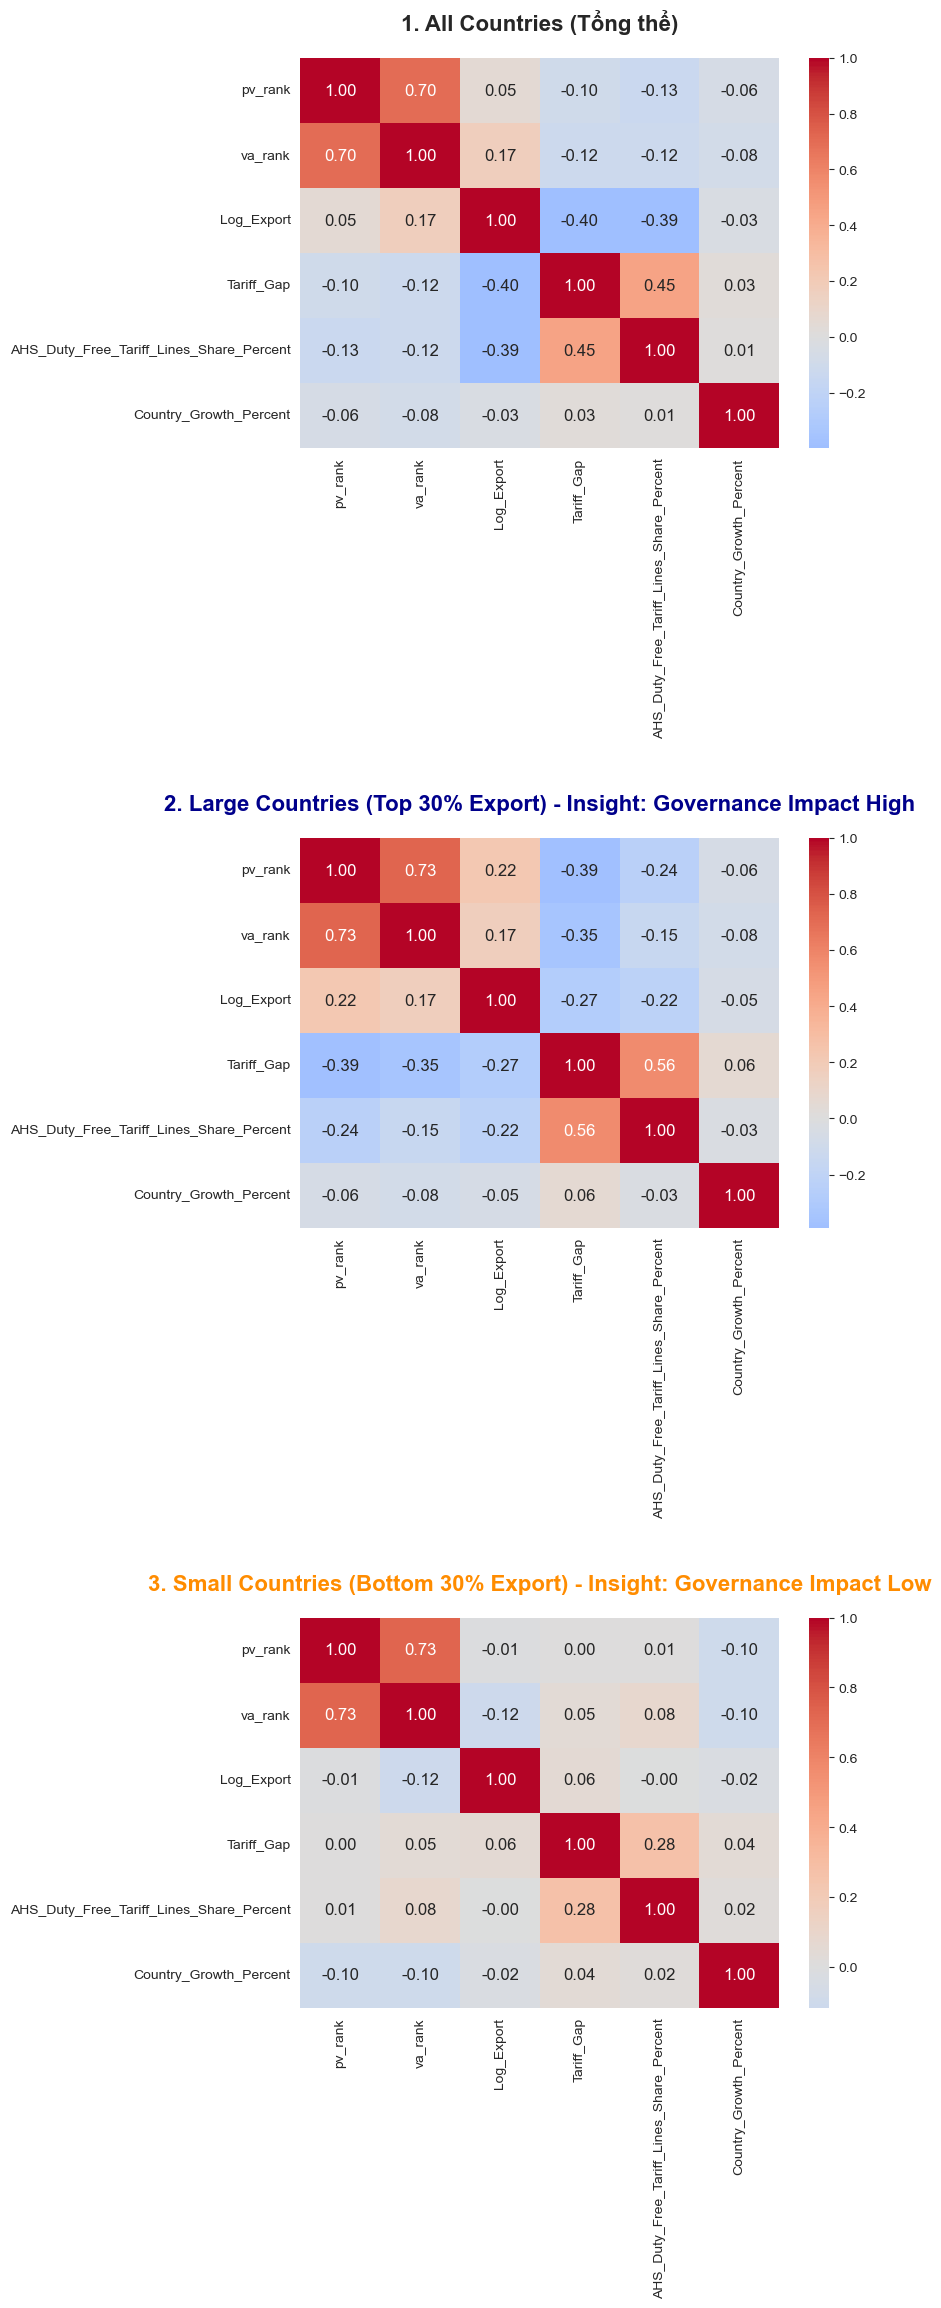

In [7]:
cols_to_corr = ['pv_rank', 'va_rank', 'Log_Export', 
                'Tariff_Gap', 'AHS_Duty_Free_Tariff_Lines_Share_Percent', 
                'Country_Growth_Percent']
available_cols = [c for c in cols_to_corr if c in df.columns]

# Phân loại Lớn/Nhỏ
high_thresh = df['Log_Export'].quantile(0.70)
low_thresh = df['Log_Export'].quantile(0.30)
large_countries = df[df['Log_Export'] >= high_thresh]
small_countries = df[df['Log_Export'] <= low_thresh]

# Tính toán Correlation
corr_all = df[available_cols].corr()
corr_large = large_countries[available_cols].corr()
corr_small = small_countries[available_cols].corr()

# VIZUALIZATION (VERTICAL STACK) 
fig, axes = plt.subplots(3, 1, figsize=(10, 24)) 

# Heatmap 1: Tổng thể
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            ax=axes[0], annot_kws={"size": 12})
axes[0].set_title(f'1. All Countries (Tổng thể)', fontsize=16, fontweight='bold', pad=20)

# Heatmap 2: Nước Lớn (Big Economies)
sns.heatmap(corr_large, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            ax=axes[1], annot_kws={"size": 12})
axes[1].set_title(f'2. Large Countries (Top 30% Export) - Insight: Governance Impact High', 
                  fontsize=16, fontweight='bold', color='darkblue', pad=20)

# Heatmap 3: Nước Nhỏ (Small Economies)
sns.heatmap(corr_small, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            ax=axes[2], annot_kws={"size": 12})
axes[2].set_title(f'3. Small Countries (Bottom 30% Export) - Insight: Governance Impact Low', 
                  fontsize=16, fontweight='bold', color='darkorange', pad=20)

# Chỉnh sửa layout để không bị đè chữ
plt.tight_layout(pad=4.0)
plt.show()

1.  **Màu sắc:** Ô giao nhau giữa `pv_rank` và `Tariff_Gap` ở biểu đồ **Large Countries** có màu xanh đậm (tương quan âm mạnh), trong khi ở **Small Countries** lại nhạt nhòa (không tương quan).
2.  **Hàm ý chính sách:**
    * Đối với nước lớn: Cải thiện quản trị (Governance) là đòn bẩy hiệu quả để giảm rào cản thương mại phi thuế quan (thể hiện qua Gap).
    * Đối với nước nhỏ: Cần các giải pháp khác ngoài quản trị để ổn định chính sách thuế.